In [120]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [121]:
df = pd.read_csv(r"C:\Users\Mr.Zabit\Documents\ml_projects\Future_ML_Projects\Future_ML_01_Sales_Forecasting\data\raw\Superstore.csv", encoding='latin-1')


In [122]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [123]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [124]:
monthly_sales = df.groupby("Order Date")["Sales"].sum()

# convert to monthly frequency
monthly_sales = monthly_sales.resample("ME").sum()

monthly_sales = monthly_sales.to_frame()

monthly_sales.head()

,Sales
Order Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


In [125]:
monthly_sales.shape

(48, 1)

In [126]:
monthly_sales["year"] = monthly_sales.index.year
monthly_sales["month"] = monthly_sales.index.month
monthly_sales["quarter"] = monthly_sales.index.quarter

In [127]:
monthly_sales["lag_1"] = monthly_sales["Sales"].shift(1)
monthly_sales["lag_2"] = monthly_sales["Sales"].shift(2)
monthly_sales["lag_3"] = monthly_sales["Sales"].shift(3)
monthly_sales["lag_6"] = monthly_sales["Sales"].shift(6)
monthly_sales["lag_12"] = monthly_sales["Sales"].shift(12)

monthly_sales["rolling_mean_3"] = monthly_sales["Sales"].shift(3).rolling(3).mean()
monthly_sales["rolling_mean_6"] = monthly_sales["Sales"].shift(1).rolling(6).mean()
monthly_sales["rolling_mean_12"] = monthly_sales["Sales"].shift(1).rolling(12).mean()

In [128]:
monthly_sales = monthly_sales.dropna()

In [129]:
X = monthly_sales.drop("Sales", axis=1)

y = monthly_sales["Sales"]

In [130]:
train = monthly_sales[:-12]
test = monthly_sales[-12:]

X_train = train.drop("Sales", axis=1)
y_train = train["Sales"]

X_test = test.drop("Sales", axis=1)
y_test = test["Sales"]

In [131]:
lr = LinearRegression()

lr.fit(X_train, y_train)


lr_pred = lr.predict(X_test)

In [132]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=40,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [133]:
def evaluate_model(actual, predicted):

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R2  :", round(r2,4))

In [134]:
print("Linear Regression Performance")

evaluate_model(y_test, lr_pred)

print("\nRandom Forest Performance")

evaluate_model(y_test, rf_pred)

Linear Regression Performance
MAE : 13950.78
RMSE: 16798.37
R2  : 0.5752

Random Forest Performance
MAE : 12431.25
RMSE: 14764.86
R2  : 0.6718


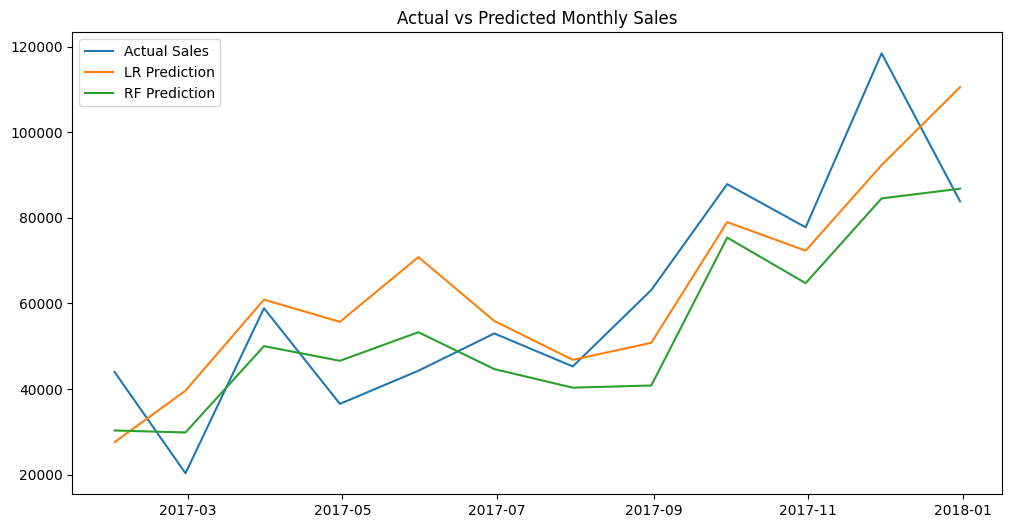

In [135]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual Sales")
plt.plot(y_test.index, lr_pred, label="LR Prediction")
plt.plot(y_test.index, rf_pred, label="RF Prediction")

plt.legend()

plt.title("Actual vs Predicted Monthly Sales")

plt.show()

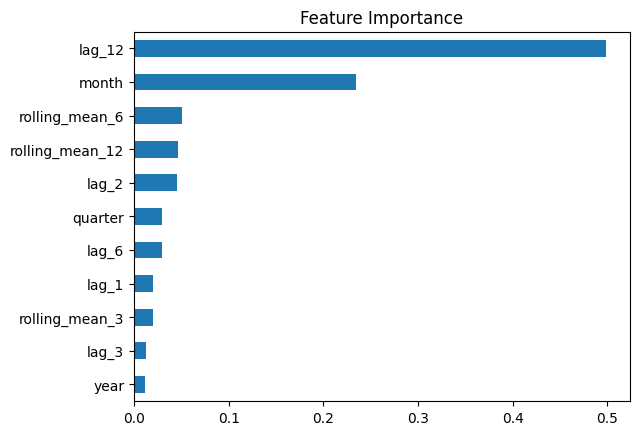

In [136]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()